# Codebook-FIGS: Definitive K-Sweep Benchmark (Iter 3)

**Codebook-constrained Fast Interpretable Greedy-tree Sums (FIGS)** with oblique splits from a shared codebook.

This notebook demonstrates:
- **Task-adaptive codebook initialization** (LDA for classification, PCA for regression)
- **WLS refinement** with orthogonality regularization
- **True FIGS-style simultaneous tree growth** via priority queue
- **Alternating optimization** with convergence tracking
- **Baselines**: FIGS (imodels), XGBoost, LightGBM

We benchmark on the **Heart Disease** dataset with a K-sweep across multiple codebook sizes.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# imodels — NOT on Colab, always install
_pip('imodels==2.0.4')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3',
         'matplotlib==3.10.0', 'xgboost==3.1.3', 'lightgbm==4.6.0')


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlxtend 0.24.0 requires matplotlib>=3.10.8, but you have matplotlib 3.10.0 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 2.0.2 which is incompatible.
mlxtend 0.24.0 requires pandas>=2.3.3, but you have pandas 2.2.2 which is incompatible.
mlxtend 0.24.0 requires scikit-learn>=1.8.0, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import json
import time
import warnings
import numpy as np
from typing import List, Dict, Tuple, Optional, Any
from collections import defaultdict
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-5c5e58-codebook-oblique-splits-learning-a-share/main/experiment_iter3_definitive_code/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['datasets'])} dataset(s)")
for ds in data['datasets']:
    print(f"  {ds['dataset']}: {len(ds['examples'])} examples")

Loaded 1 dataset(s)
  heart_disease: 100 examples


## Configuration

All tunable parameters for the Codebook-FIGS experiment. Adjust these to control the scope and runtime of the benchmark.

In [5]:
# ── Codebook-FIGS hyperparameters ──
K_VALUES = [3, 5, 8, 12, 20]   # codebook sizes to sweep
N_FOLDS = 5                     # number of cross-validation folds
MAX_RULES = 12                  # max splits across all trees
MAX_DEPTH = 4                   # max tree depth
N_ALTERNATION_ROUNDS = 7        # codebook-tree alternation rounds
MIN_SAMPLES_LEAF = 5            # minimum samples per leaf
ORTHO_LAMBDA = 0.1              # orthogonality regularization strength

# ── Baseline configs ──
CB_CONFIGS = [
    {"name": "cb_figs_adaptive", "init": "adaptive", "lambda": ORTHO_LAMBDA},
    {"name": "cb_figs_random",   "init": "random",   "lambda": ORTHO_LAMBDA},
]
BASELINES = ["figs", "xgboost", "lightgbm"]

## Phase 1: Data Loading

Parse the JSON dataset into numpy arrays with fold assignments for cross-validation.

In [6]:
def load_datasets(raw: dict) -> Dict[str, Dict[str, Any]]:
    """Parse JSON data into numpy arrays.

    Returns dict: dataset_name -> {X, y, folds, task_type, n_classes, feature_names, ...}
    """
    datasets: Dict[str, Dict[str, Any]] = {}

    for group in raw["datasets"]:
        name = group["dataset"]
        examples = group["examples"]
        if len(examples) == 0:
            continue

        meta = examples[0]
        task_type = meta["metadata_task_type"]
        n_classes = meta.get("metadata_n_classes", 0)
        feature_names = meta.get("metadata_feature_names", [])

        X_list, y_list, fold_list = [], [], []
        for ex in examples:
            X_list.append(json.loads(ex["input"]))
            y_list.append(float(ex["output"]))
            fold_list.append(int(ex["metadata_fold"]))

        X = np.array(X_list, dtype=np.float64)
        y = np.array(y_list, dtype=np.float64)
        folds = np.array(fold_list, dtype=int)

        datasets[name] = {
            "X": X, "y": y, "folds": folds,
            "task_type": task_type,
            "n_classes": int(n_classes),
            "feature_names": feature_names,
            "n_features": X.shape[1],
            "n_samples": X.shape[0],
        }
        print(f"  {name}: n={X.shape[0]}, d={X.shape[1]}, task={task_type}, folds={len(np.unique(folds))}")

    return datasets

datasets = load_datasets(data)
print(f"\nLoaded {len(datasets)} dataset(s)")

  heart_disease: n=100, d=25, task=classification, folds=5

Loaded 1 dataset(s)


## Phase 2: Tree Node Class

Each node in a Codebook-FIGS tree stores an oblique split defined by a codebook index and threshold.

In [7]:
class Node:
    """Tree node for Codebook-FIGS, supporting oblique splits from a shared codebook."""
    __slots__ = [
        "codebook_idx", "weights", "threshold", "value",
        "idxs", "left", "right", "left_temp", "right_temp",
        "impurity_reduction", "is_root", "tree_num", "depth", "n_samples",
    ]

    def __init__(self) -> None:
        self.codebook_idx: Optional[int] = None
        self.weights: Optional[np.ndarray] = None
        self.threshold: Optional[float] = None
        self.value: float = 0.0
        self.idxs: Optional[np.ndarray] = None
        self.left: Optional["Node"] = None
        self.right: Optional["Node"] = None
        self.left_temp: Optional["Node"] = None
        self.right_temp: Optional["Node"] = None
        self.impurity_reduction: Optional[float] = None
        self.is_root: bool = False
        self.tree_num: int = -1
        self.depth: int = 0
        self.n_samples: int = 0

## Phase 3: Codebook Initialization Strategies

Four codebook initialization strategies: PCA, random, LDA (between-class scatter SVD), and task-adaptive (LDA for classification, PCA for regression).

In [8]:
def init_codebook_pca(X_train: np.ndarray, K: int) -> np.ndarray:
    """Top-K PCA components of centered, scaled X_train."""
    from sklearn.decomposition import PCA

    X_centered = X_train - X_train.mean(axis=0)
    K_actual = min(K, X_train.shape[0], X_train.shape[1])
    pca = PCA(n_components=K_actual)
    pca.fit(X_centered)
    C = pca.components_.copy()

    if K_actual < K:
        rng = np.random.RandomState(42)
        extra = rng.randn(K - K_actual, X_train.shape[1])
        extra = extra / (np.linalg.norm(extra, axis=1, keepdims=True) + 1e-12)
        C = np.vstack([C, extra])

    norms = np.linalg.norm(C, axis=1, keepdims=True)
    C = C / np.maximum(norms, 1e-12)
    return C


def init_codebook_random(X_train: np.ndarray, K: int, seed: int = 42) -> np.ndarray:
    """K random unit vectors."""
    rng = np.random.RandomState(seed)
    C = rng.randn(K, X_train.shape[1])
    C = C / (np.linalg.norm(C, axis=1, keepdims=True) + 1e-12)
    return C


def init_codebook_lda(
    X_train: np.ndarray, y_train: np.ndarray, K: int, task_type: str,
) -> np.ndarray:
    """LDA-inspired init via between-class scatter SVD."""
    try:
        if task_type == "regression":
            n_bins = min(10, max(2, len(np.unique(y_train)) // 2))
            from sklearn.preprocessing import KBinsDiscretizer
            kbd = KBinsDiscretizer(n_bins=n_bins, encode="ordinal", strategy="quantile")
            y_binned = kbd.fit_transform(y_train.reshape(-1, 1)).ravel().astype(int)
        else:
            y_binned = y_train.astype(int)

        classes = np.unique(y_binned)
        n_features = X_train.shape[1]
        mu = X_train.mean(axis=0)

        S_B = np.zeros((n_features, n_features))
        for c in classes:
            mask = y_binned == c
            n_c = mask.sum()
            if n_c == 0:
                continue
            mu_c = X_train[mask].mean(axis=0)
            diff = mu_c - mu
            S_B += n_c * np.outer(diff, diff)

        _U, _S_vals, Vt = np.linalg.svd(S_B)
        n_lda = min(len(classes) - 1, n_features, K)
        n_lda = max(n_lda, 1)

        C_lda = Vt[:n_lda].copy()
        norms = np.linalg.norm(C_lda, axis=1, keepdims=True)
        C_lda = C_lda / np.maximum(norms, 1e-12)

        if n_lda < K:
            C_pca = init_codebook_pca(X_train, K)
            C = np.vstack([C_lda, C_pca[n_lda:K]])
        else:
            C = C_lda[:K]

        norms = np.linalg.norm(C, axis=1, keepdims=True)
        C = C / np.maximum(norms, 1e-12)
        return C
    except Exception:
        return init_codebook_pca(X_train, K)


def init_codebook_adaptive(
    X_train: np.ndarray, y_train: np.ndarray, K: int, task_type: str, seed: int = 42,
) -> np.ndarray:
    """Task-adaptive: LDA for classification, PCA for regression."""
    if task_type == "classification":
        return init_codebook_lda(X_train, y_train, K, task_type)
    else:
        return init_codebook_pca(X_train, K)

## Phase 4: Split Search

Find the best oblique split by projecting data onto each codebook direction and scanning for the best threshold via sorted-scan impurity reduction.

In [9]:
def find_best_codebook_split(
    X: np.ndarray, y_residuals: np.ndarray, idxs: np.ndarray,
    codebook: np.ndarray, min_samples_leaf: int = 5, quantile_threshold: int = 5000,
) -> Tuple[Optional[int], Optional[float], float, Optional[np.ndarray], Optional[np.ndarray]]:
    """Find best (codebook direction, threshold) split by sorted-scan impurity reduction."""
    node_indices = np.where(idxs)[0]
    n_node = len(node_indices)

    if n_node < 2 * min_samples_leaf:
        return None, None, -np.inf, None, None

    X_node = X[node_indices]
    y_node = y_residuals[node_indices]
    parent_var = np.var(y_node) * n_node

    best_k: Optional[int] = None
    best_threshold: Optional[float] = None
    best_reduction = -np.inf
    K = codebook.shape[0]

    use_quantiles = n_node > quantile_threshold
    n_quantiles = 100

    for k in range(K):
        proj = X_node @ codebook[k]
        order = np.argsort(proj)
        sorted_proj = proj[order]
        sorted_y = y_node[order]

        cum_sum = np.cumsum(sorted_y)
        cum_sq_sum = np.cumsum(sorted_y ** 2)
        total_sum = cum_sum[-1]
        total_sq_sum = cum_sq_sum[-1]

        if use_quantiles:
            positions = np.linspace(
                min_samples_leaf - 1, n_node - min_samples_leaf - 1,
                min(n_quantiles, n_node - 2 * min_samples_leaf),
            ).astype(int)
            positions = np.unique(positions)
        else:
            positions = np.arange(min_samples_leaf - 1, n_node - min_samples_leaf)

        for i in positions:
            if i + 1 < n_node and sorted_proj[i] == sorted_proj[i + 1]:
                continue
            n_left = i + 1
            n_right = n_node - n_left
            left_sum = cum_sum[i]
            right_sum = total_sum - left_sum
            left_mse = cum_sq_sum[i] - (left_sum ** 2) / n_left
            right_mse = (total_sq_sum - cum_sq_sum[i]) - (right_sum ** 2) / n_right
            reduction = parent_var - left_mse - right_mse

            if reduction > best_reduction:
                best_reduction = reduction
                best_k = k
                if i + 1 < n_node:
                    best_threshold = (sorted_proj[i] + sorted_proj[i + 1]) / 2.0
                else:
                    best_threshold = sorted_proj[i]

    if best_k is None:
        return None, None, -np.inf, None, None

    full_proj = X @ codebook[best_k]
    idxs_left = idxs & (full_proj <= best_threshold)
    idxs_right = idxs & (full_proj > best_threshold)
    return best_k, best_threshold, best_reduction, idxs_left, idxs_right

## Phase 5: Effective Rank & Codebook Stability

Metrics for measuring codebook diversity (effective rank via SVD entropy) and cross-fold stability (Hungarian-aligned cosine similarity).

In [10]:
def effective_rank(C: np.ndarray, eps: float = 1e-12) -> float:
    """eRank = exp(entropy of normalized singular values)."""
    s = np.linalg.svd(C, compute_uv=False)
    s = s[s > eps]
    if len(s) == 0:
        return 0.0
    p = s / np.sum(s)
    entropy = -np.sum(p * np.log(p + 1e-30))
    return float(np.exp(entropy))


def align_codebooks_hungarian(
    C_ref: np.ndarray, C_target: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Align C_target to C_ref using Hungarian algorithm on |cosine similarity|."""
    from scipy.optimize import linear_sum_assignment
    from sklearn.metrics.pairwise import cosine_similarity

    cos_sim = cosine_similarity(C_ref, C_target)
    abs_cos_sim = np.abs(cos_sim)
    row_ind, col_ind = linear_sum_assignment(abs_cos_sim, maximize=True)

    C_aligned = C_target[col_ind].copy()
    matched_sims = []
    for i in range(len(row_ind)):
        sim = cos_sim[row_ind[i], col_ind[i]]
        matched_sims.append(abs(sim))
        if sim < 0:
            C_aligned[i] *= -1

    return C_aligned, col_ind, np.array(matched_sims)


def compute_codebook_stability(codebooks: List[np.ndarray]) -> Dict[str, Any]:
    """Compute codebook stability across CV folds via Hungarian alignment."""
    if len(codebooks) < 2:
        return {"mean_cosine_sim": 1.0, "min_cosine_sim": 1.0}

    C_ref = codebooks[0]
    all_sims = []
    for fold_idx in range(1, len(codebooks)):
        _, _, sims = align_codebooks_hungarian(C_ref, codebooks[fold_idx])
        all_sims.append(sims)

    all_sims_arr = np.array(all_sims)
    return {
        "mean_cosine_sim": float(np.mean(all_sims_arr)),
        "min_cosine_sim": float(np.min(all_sims_arr)),
    }

## Phase 6: Codebook-FIGS Model

The core model class implementing alternating optimization between tree structure and codebook directions, with FIGS-style simultaneous tree growth, WLS codebook refinement, and orthogonality regularization.

In [11]:
class CodebookFIGS:
    """Codebook-constrained FIGS with all iter3 improvements."""

    def __init__(
        self, K: int = 8, max_rules: int = 12, max_trees: Optional[int] = None,
        max_depth: int = 4, min_impurity_decrease: float = 0.0,
        n_alternation_rounds: int = 7, init_strategy: str = "adaptive",
        refine_strategy: str = "wls", ortho_lambda: float = 0.01,
        random_state: int = 42, min_samples_leaf: int = 5,
    ) -> None:
        self.K = K
        self.max_rules = max_rules
        self.max_trees = max_trees if max_trees else 10
        self.max_depth = max_depth
        self.min_impurity_decrease = min_impurity_decrease
        self.n_alternation_rounds = n_alternation_rounds
        self.init_strategy = init_strategy
        self.refine_strategy = refine_strategy
        self.ortho_lambda = ortho_lambda
        self.random_state = random_state
        self.min_samples_leaf = min_samples_leaf
        self.trees_: List[Node] = []
        self.codebook_: Optional[np.ndarray] = None
        self.scaler_: Any = None
        self.task_type_: str = "classification"
        self.complexity_: int = 0
        self.history_: Dict[str, list] = {}
        self.converged_at_round_: int = 0

    def fit(self, X: np.ndarray, y: np.ndarray, task_type: str = "classification") -> "CodebookFIGS":
        from sklearn.preprocessing import StandardScaler
        self.task_type_ = task_type
        self.scaler_ = StandardScaler()
        X_s = self.scaler_.fit_transform(X)

        if self.init_strategy == "adaptive":
            self.codebook_ = init_codebook_adaptive(X_s, y, self.K, task_type, self.random_state)
        elif self.init_strategy == "random":
            self.codebook_ = init_codebook_random(X_s, self.K, self.random_state)
        elif self.init_strategy == "pca":
            self.codebook_ = init_codebook_pca(X_s, self.K)
        elif self.init_strategy == "lda":
            self.codebook_ = init_codebook_lda(X_s, y, self.K, task_type)
        else:
            raise ValueError(f"Unknown init_strategy: {self.init_strategy}")

        self.history_ = {"train_losses": [], "eranks": [], "n_splits": [], "primary_metric": [], "codebooks": []}
        initial_loss, prev_loss = None, None

        for round_idx in range(self.n_alternation_rounds):
            self._grow_trees_figs_style(X_s, y)
            preds = self._predict_raw(X_s)
            loss = float(np.mean((y - preds) ** 2))
            if task_type == "classification":
                metric = float(np.mean((preds >= 0.5).astype(int) == y.astype(int)))
            else:
                ss_res = np.sum((y - preds) ** 2)
                ss_tot = np.sum((y - y.mean()) ** 2)
                metric = 1.0 - ss_res / max(ss_tot, 1e-12)

            self.history_["train_losses"].append(loss)
            self.history_["primary_metric"].append(float(metric))
            self.history_["eranks"].append(effective_rank(self.codebook_))
            self.history_["n_splits"].append(self.complexity_)
            self.history_["codebooks"].append(self.codebook_.copy())

            if initial_loss is None:
                initial_loss = loss

            if round_idx < self.n_alternation_rounds - 1:
                self._refine_codebook_wls(X_s, y)
                if self.ortho_lambda > 0:
                    self._apply_ortho_regularization()
                self._check_codebook_collapse()
                if prev_loss is not None and initial_loss is not None and initial_loss > 0:
                    if abs(loss - prev_loss) < 0.005 * initial_loss:
                        self.converged_at_round_ = round_idx + 1
                        self._grow_trees_figs_style(X_s, y)
                        break
            prev_loss = loss

        if self.converged_at_round_ == 0:
            self.converged_at_round_ = len(self.history_["train_losses"])
        return self

    def _grow_trees_figs_style(self, X: np.ndarray, y: np.ndarray) -> None:
        n_samples = X.shape[0]
        self.trees_ = []
        self.complexity_ = 0
        y_pred_per_tree: Dict[int, np.ndarray] = {}
        all_idxs = np.ones(n_samples, dtype=bool)

        bk, bt, br, il, ir = find_best_codebook_split(X, y, all_idxs, self.codebook_, self.min_samples_leaf)
        if bk is None:
            root = Node()
            root.is_root = True; root.tree_num = 0; root.idxs = all_idxs
            root.value = float(np.mean(y)); root.n_samples = n_samples
            self.trees_.append(root)
            return

        root = Node()
        root.is_root = True; root.tree_num = -1; root.idxs = all_idxs
        root.value = float(np.mean(y)); root.impurity_reduction = br
        root.codebook_idx = bk; root.weights = self.codebook_[bk].copy()
        root.threshold = bt; root.depth = 0; root.n_samples = n_samples

        root.left_temp = Node()
        root.left_temp.idxs = il
        root.left_temp.value = float(np.mean(y[il])) if il.sum() > 0 else 0.0
        root.left_temp.n_samples = int(il.sum()); root.left_temp.depth = 1

        root.right_temp = Node()
        root.right_temp.idxs = ir
        root.right_temp.value = float(np.mean(y[ir])) if ir.sum() > 0 else 0.0
        root.right_temp.n_samples = int(ir.sum()); root.right_temp.depth = 1

        potential_splits: List[Node] = [root]
        max_new_trees = self.max_trees

        while potential_splits and self.complexity_ < self.max_rules:
            potential_splits.sort(
                key=lambda n: n.impurity_reduction if n.impurity_reduction is not None else -np.inf,
                reverse=True,
            )
            best_node = potential_splits.pop(0)
            if best_node.impurity_reduction is None or best_node.impurity_reduction < self.min_impurity_decrease:
                break
            if self.max_depth is not None and best_node.depth >= self.max_depth:
                continue
            if best_node.is_root:
                if len(self.trees_) >= max_new_trees:
                    continue
                best_node.tree_num = len(self.trees_)
                self.trees_.append(best_node)
                y_pred_per_tree[best_node.tree_num] = np.full(n_samples, best_node.value)

            self.complexity_ += 1
            best_node.left = best_node.left_temp
            best_node.right = best_node.right_temp
            best_node.left.tree_num = best_node.tree_num
            best_node.right.tree_num = best_node.tree_num
            best_node.left_temp = None; best_node.right_temp = None

            tree_root = self.trees_[best_node.tree_num]
            y_pred_per_tree[best_node.tree_num] = self._predict_tree(tree_root, X)

            for child in [best_node.left, best_node.right]:
                if child.n_samples < 2 * self.min_samples_leaf:
                    continue
                y_res = y.copy()
                for other_t, pred in y_pred_per_tree.items():
                    if other_t != child.tree_num:
                        y_res -= pred
                bk2, bt2, br2, il2, ir2 = find_best_codebook_split(
                    X, y_res, child.idxs, self.codebook_, self.min_samples_leaf)
                if bk2 is not None and br2 > self.min_impurity_decrease:
                    child.codebook_idx = bk2; child.weights = self.codebook_[bk2].copy()
                    child.threshold = bt2; child.impurity_reduction = br2
                    child.left_temp = Node()
                    child.left_temp.idxs = il2
                    child.left_temp.value = float(np.mean(y_res[il2])) if il2.sum() > 0 else 0.0
                    child.left_temp.n_samples = int(il2.sum()); child.left_temp.depth = child.depth + 1
                    child.right_temp = Node()
                    child.right_temp.idxs = ir2
                    child.right_temp.value = float(np.mean(y_res[ir2])) if ir2.sum() > 0 else 0.0
                    child.right_temp.n_samples = int(ir2.sum()); child.right_temp.depth = child.depth + 1
                    potential_splits.append(child)

            if len(self.trees_) < max_new_trees:
                y_total = np.zeros(n_samples)
                for pred in y_pred_per_tree.values():
                    y_total += pred
                y_res_new = y - y_total
                bk3, bt3, br3, il3, ir3 = find_best_codebook_split(
                    X, y_res_new, np.ones(n_samples, dtype=bool), self.codebook_, self.min_samples_leaf)
                if bk3 is not None and br3 > self.min_impurity_decrease:
                    new_root = Node()
                    new_root.is_root = True; new_root.tree_num = -1
                    new_root.idxs = np.ones(n_samples, dtype=bool)
                    new_root.value = float(np.mean(y_res_new)); new_root.impurity_reduction = br3
                    new_root.codebook_idx = bk3; new_root.weights = self.codebook_[bk3].copy()
                    new_root.threshold = bt3; new_root.depth = 0; new_root.n_samples = n_samples
                    new_root.left_temp = Node()
                    new_root.left_temp.idxs = il3
                    new_root.left_temp.value = float(np.mean(y_res_new[il3])) if il3.sum() > 0 else 0.0
                    new_root.left_temp.n_samples = int(il3.sum()); new_root.left_temp.depth = 1
                    new_root.right_temp = Node()
                    new_root.right_temp.idxs = ir3
                    new_root.right_temp.value = float(np.mean(y_res_new[ir3])) if ir3.sum() > 0 else 0.0
                    new_root.right_temp.n_samples = int(ir3.sum()); new_root.right_temp.depth = 1
                    potential_splits.append(new_root)

    def _refine_codebook_wls(self, X: np.ndarray, y: np.ndarray) -> None:
        K, n_features = self.codebook_.shape
        for k in range(K):
            nodes_k: List[Node] = []
            for tree in self.trees_:
                self._collect_nodes_with_idx(tree, k, nodes_k)
            if not nodes_k:
                rng = np.random.RandomState(self.random_state + k + 200)
                self.codebook_[k] = rng.randn(n_features)
                self.codebook_[k] /= np.linalg.norm(self.codebook_[k]) + 1e-12
                continue
            X_pool_list, y_res_list = [], []
            for node in nodes_k:
                y_res = y.copy()
                for t_idx, tree in enumerate(self.trees_):
                    if t_idx != node.tree_num:
                        y_res -= self._predict_tree(tree, X)
                X_pool_list.append(X[node.idxs])
                y_res_list.append(y_res[node.idxs])
            X_pool = np.vstack(X_pool_list)
            y_pool = np.concatenate(y_res_list)
            direction = X_pool.T @ y_pool
            norm = np.linalg.norm(direction)
            if norm > 1e-12:
                self.codebook_[k] = direction / norm

    def _collect_nodes_with_idx(self, node: Optional[Node], k: int, result: List[Node]) -> None:
        if node is None:
            return
        if node.left is not None and node.right is not None:
            if node.codebook_idx == k:
                result.append(node)
            self._collect_nodes_with_idx(node.left, k, result)
            self._collect_nodes_with_idx(node.right, k, result)

    def _apply_ortho_regularization(self) -> None:
        if self.ortho_lambda <= 0:
            return
        C = self.codebook_
        K = C.shape[0]
        G = C @ C.T
        I_K = np.eye(K)
        grad = 4.0 * (G - I_K) @ C
        C_new = C - self.ortho_lambda * grad
        norms = np.linalg.norm(C_new, axis=1, keepdims=True)
        self.codebook_ = C_new / np.maximum(norms, 1e-12)

    def _check_codebook_collapse(self) -> int:
        from sklearn.metrics.pairwise import cosine_similarity
        K = self.codebook_.shape[0]
        n_feat = self.codebook_.shape[1]
        cos_sim = np.abs(cosine_similarity(self.codebook_))
        np.fill_diagonal(cos_sim, 0.0)
        n_collapses = 0
        for i in range(K):
            for j in range(i + 1, K):
                if cos_sim[i, j] > 0.99:
                    rng = np.random.RandomState(self.random_state + 100 + j)
                    self.codebook_[j] = rng.randn(n_feat)
                    self.codebook_[j] /= np.linalg.norm(self.codebook_[j]) + 1e-12
                    n_collapses += 1
        return n_collapses

    def _predict_tree(self, root: Node, X: np.ndarray) -> np.ndarray:
        preds = np.full(X.shape[0], root.value)
        if root.left is not None and root.right is not None:
            proj = X @ root.weights
            left_mask = proj <= root.threshold
            left_preds = self._predict_tree(root.left, X)
            right_preds = self._predict_tree(root.right, X)
            preds[left_mask] = left_preds[left_mask]
            preds[~left_mask] = right_preds[~left_mask]
        return preds

    def _predict_raw(self, X: np.ndarray) -> np.ndarray:
        if not self.trees_:
            return np.zeros(X.shape[0])
        return sum(self._predict_tree(t, X) for t in self.trees_)

    def predict(self, X_raw: np.ndarray) -> np.ndarray:
        X = self.scaler_.transform(X_raw)
        raw = self._predict_raw(X)
        if self.task_type_ == "classification":
            return (raw >= 0.5).astype(int)
        return raw

    def predict_proba(self, X_raw: np.ndarray) -> np.ndarray:
        X = self.scaler_.transform(X_raw)
        raw = self._predict_raw(X)
        probs = np.clip(raw, 0.0, 1.0)
        return np.column_stack([1 - probs, probs])

    def get_codebook_usage(self) -> Dict[int, int]:
        usage: Dict[int, int] = defaultdict(int)
        for tree in self.trees_:
            self._count_usage(tree, usage)
        return dict(usage)

    def _count_usage(self, node: Optional[Node], usage: Dict[int, int]) -> None:
        if node is None:
            return
        if node.left is not None and node.right is not None:
            if node.codebook_idx is not None:
                usage[node.codebook_idx] += 1
            self._count_usage(node.left, usage)
            self._count_usage(node.right, usage)

print("CodebookFIGS class defined.")

CodebookFIGS class defined.


## Phase 7: Baselines & Evaluation

FIGS (imodels), XGBoost, and LightGBM baselines, plus per-fold metric computation.

In [12]:
def run_figs_baseline(X_train, y_train, X_test, task_type, max_rules=12):
    """FIGS from imodels. Returns (y_pred, y_proba, n_splits)."""
    from imodels import FIGSClassifier, FIGSRegressor
    if task_type == "classification":
        model = FIGSClassifier(max_rules=max_rules)
    else:
        model = FIGSRegressor(max_rules=max_rules)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = None
    if task_type == "classification":
        try: y_proba = model.predict_proba(X_test)
        except Exception: pass
    n_splits = getattr(model, "complexity_", 0)
    return y_pred, y_proba, n_splits


def run_xgboost_baseline(X_train, y_train, X_test, task_type):
    import xgboost as xgb
    if task_type == "classification":
        model = xgb.XGBClassifier(max_depth=4, n_estimators=100, learning_rate=0.1,
                                   random_state=42, eval_metric="logloss", verbosity=0)
    else:
        model = xgb.XGBRegressor(max_depth=4, n_estimators=100, learning_rate=0.1,
                                  random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = None
    if task_type == "classification":
        try: y_proba = model.predict_proba(X_test)
        except Exception: pass
    return y_pred, y_proba


def run_lgbm_baseline(X_train, y_train, X_test, task_type):
    import lightgbm as lgb
    if task_type == "classification":
        model = lgb.LGBMClassifier(max_depth=4, n_estimators=100, learning_rate=0.1,
                                    random_state=42, verbose=-1)
    else:
        model = lgb.LGBMRegressor(max_depth=4, n_estimators=100, learning_rate=0.1,
                                   random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = None
    if task_type == "classification":
        try: y_proba = model.predict_proba(X_test)
        except Exception: pass
    return y_pred, y_proba


def evaluate_fold(y_true, y_pred, y_proba, task_type):
    from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, r2_score
    metrics = {}
    if task_type == "classification":
        metrics["accuracy"] = float(accuracy_score(y_true, y_pred))
        if y_proba is not None:
            try:
                proba_1 = np.clip(y_proba[:, 1], 1e-7, 1 - 1e-7)
                metrics["auroc"] = float(roc_auc_score(y_true, proba_1))
            except ValueError:
                metrics["auroc"] = None
        else:
            metrics["auroc"] = None
    else:
        metrics["rmse"] = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        metrics["r2"] = float(r2_score(y_true, y_pred))
    return metrics

print("Baselines and evaluation functions defined.")

Baselines and evaluation functions defined.


## Phase 8: Run Benchmark

Cross-validated benchmark: for each fold, run baselines (FIGS, XGBoost, LightGBM) and Codebook-FIGS with each init strategy across all K values.

In [13]:
start_time = time.time()
all_results = []
codebook_archive = {}

for ds_name, ds_info in sorted(datasets.items()):
    X, y = ds_info["X"], ds_info["y"]
    folds, task_type = ds_info["folds"], ds_info["task_type"]
    n_features = ds_info["n_features"]

    print(f"\n=== {ds_name} ({task_type}, n={X.shape[0]}, d={X.shape[1]}) ===")

    unique_folds = sorted(np.unique(folds))
    actual_n_folds = min(N_FOLDS, len(unique_folds))

    for fold_idx in range(actual_n_folds):
        fold_val = unique_folds[fold_idx]
        test_mask = folds == fold_val
        train_mask = ~test_mask
        if test_mask.sum() == 0 or train_mask.sum() == 0:
            continue

        X_tr, X_te = X[train_mask], X[test_mask]
        y_tr, y_te = y[train_mask], y[test_mask]

        # ── Baselines ──
        for baseline_name in BASELINES:
            t0 = time.time()
            try:
                if baseline_name == "figs":
                    y_pred, y_proba, n_splits = run_figs_baseline(X_tr, y_tr, X_te, task_type, MAX_RULES)
                elif baseline_name == "xgboost":
                    y_pred, y_proba = run_xgboost_baseline(X_tr, y_tr, X_te, task_type)
                    n_splits = None
                elif baseline_name == "lightgbm":
                    y_pred, y_proba = run_lgbm_baseline(X_tr, y_tr, X_te, task_type)
                    n_splits = None
                else:
                    continue

                elapsed = time.time() - t0
                metrics = evaluate_fold(y_te, y_pred, y_proba, task_type)
                all_results.append({
                    "dataset": ds_name, "method": baseline_name, "config": baseline_name,
                    "K": None, "fold": fold_idx, "train_time_sec": round(elapsed, 4),
                    "n_splits": n_splits, "erank": None, "n_codebook_used": None,
                    "codebook_stability_mean": None, "converged_at_round": None,
                    **metrics,
                })
                print(f"  {baseline_name} fold={fold_idx}: {metrics} ({elapsed:.2f}s)")
            except Exception as e:
                print(f"  {baseline_name} fold={fold_idx} FAILED: {e}")

        # ── Codebook-FIGS ──
        for cfg in CB_CONFIGS:
            for K in K_VALUES:
                K_actual = min(K, n_features)
                t0 = time.time()
                try:
                    model = CodebookFIGS(
                        K=K_actual, max_rules=MAX_RULES, max_depth=MAX_DEPTH,
                        n_alternation_rounds=N_ALTERNATION_ROUNDS,
                        init_strategy=cfg["init"], ortho_lambda=cfg["lambda"],
                        random_state=42 + fold_idx, min_samples_leaf=MIN_SAMPLES_LEAF,
                    )
                    model.fit(X_tr, y_tr, task_type)
                    elapsed = time.time() - t0

                    if task_type == "classification":
                        y_pred = model.predict(X_te)
                        y_proba = model.predict_proba(X_te)
                    else:
                        y_pred = model.predict(X_te)
                        y_proba = None

                    metrics = evaluate_fold(y_te, y_pred, y_proba, task_type)
                    usage = model.get_codebook_usage()
                    usage_array = np.array([usage.get(k, 0) for k in range(K_actual)], dtype=float)
                    erank = effective_rank(model.codebook_)
                    n_used = int(np.sum(usage_array > 0))

                    codebook_archive[(ds_name, cfg["name"], K, fold_idx)] = model.codebook_.copy()

                    all_results.append({
                        "dataset": ds_name, "method": "codebook_figs", "config": cfg["name"],
                        "K": K, "fold": fold_idx, "train_time_sec": round(elapsed, 4),
                        "n_splits": model.complexity_, "erank": round(erank, 4),
                        "n_codebook_used": n_used, "codebook_stability_mean": None,
                        "converged_at_round": model.converged_at_round_,
                        **metrics,
                    })
                    print(f"  {cfg['name']} K={K} fold={fold_idx}: {metrics}, erank={erank:.2f}, "
                          f"used={n_used}/{K_actual}, converged@{model.converged_at_round_} ({elapsed:.2f}s)")
                except Exception as e:
                    print(f"  {cfg['name']} K={K} fold={fold_idx} FAILED: {e}")

elapsed_total = time.time() - start_time
print(f"\nBenchmark complete: {len(all_results)} result rows in {elapsed_total:.1f}s")


=== heart_disease (classification, n=100, d=25) ===


  figs fold=0: {'accuracy': 0.85, 'auroc': 0.9500000000000001} (1.41s)


  xgboost fold=0: {'accuracy': 0.9, 'auroc': 0.9500000000000001} (0.21s)
  lightgbm fold=0: {'accuracy': 0.9, 'auroc': 0.9400000000000001} (0.03s)
  cb_figs_adaptive K=3 fold=0: {'accuracy': 0.85, 'auroc': 0.87}, erank=2.84, used=3/3, converged@7 (0.14s)


  cb_figs_adaptive K=5 fold=0: {'accuracy': 0.8, 'auroc': 0.865}, erank=4.93, used=4/5, converged@7 (0.15s)


  cb_figs_adaptive K=8 fold=0: {'accuracy': 0.75, 'auroc': 0.81}, erank=7.26, used=5/8, converged@7 (0.22s)


...

  cb_figs_adaptive K=20 fold=4: {'accuracy': 0.9, 'auroc': 0.9849999999999999}, erank=18.59, used=7/20, converged@7 (0.56s)
  cb_figs_random K=3 fold=4: {'accuracy': 0.85, 'auroc': 0.94}, erank=2.91, used=2/3, converged@7 (0.13s)


  cb_figs_random K=5 fold=4: {'accuracy': 0.85, 'auroc': 0.925}, erank=4.94, used=4/5, converged@7 (0.18s)


  cb_figs_random K=8 fold=4: {'accuracy': 0.9, 'auroc': 1.0}, erank=7.48, used=4/8, converged@7 (0.25s)


  cb_figs_random K=12 fold=4: {'accuracy': 0.8, 'auroc': 0.905}, erank=10.79, used=9/12, converged@7 (0.38s)


  cb_figs_random K=20 fold=4: {'accuracy': 0.85, 'auroc': 0.8600000000000001}, erank=17.37, used=7/20, converged@7 (0.74s)

Benchmark complete: 65 result rows in 33.0s


## Phase 9: Codebook Stability & Summary Aggregation

Compute codebook stability across folds, then aggregate per-fold results into mean/std per (dataset, config, K).

In [14]:
# ── Compute codebook stability ──
for ds_name in datasets:
    for cfg in CB_CONFIGS:
        for K in K_VALUES:
            fold_codebooks = []
            for fold_idx in range(N_FOLDS):
                key = (ds_name, cfg["name"], K, fold_idx)
                if key in codebook_archive:
                    fold_codebooks.append(codebook_archive[key])
            if len(fold_codebooks) >= 2:
                stability = compute_codebook_stability(fold_codebooks)
                mean_sim = stability["mean_cosine_sim"]
            else:
                mean_sim = None
            for r in all_results:
                if (r["dataset"] == ds_name and r.get("config") == cfg["name"]
                        and r.get("K") == K and r["method"] == "codebook_figs"):
                    r["codebook_stability_mean"] = mean_sim

# ── Aggregate results ──
def compute_summary(all_results):
    groups = defaultdict(list)
    for r in all_results:
        key = (r["dataset"], r.get("config", r["method"]), r.get("K"))
        groups[key].append(r)
    summary_rows = []
    agg_cols = ["accuracy", "auroc", "rmse", "r2", "erank", "n_splits",
                "train_time_sec", "n_codebook_used", "codebook_stability_mean", "converged_at_round"]
    for (ds, config, K), rows in groups.items():
        row = {"dataset": ds, "config": config, "K": K}
        for col in agg_cols:
            vals = [r.get(col) for r in rows if r.get(col) is not None]
            if vals:
                arr = np.array(vals, dtype=float)
                row[f"{col}_mean"] = float(np.nanmean(arr))
                row[f"{col}_std"] = float(np.nanstd(arr))
        summary_rows.append(row)
    return summary_rows

summary = compute_summary(all_results)
print(f"Summary: {len(summary)} rows")
for s in summary:
    K_str = f"K={s['K']}" if s['K'] else "   "
    acc = s.get('accuracy_mean', None)
    acc_str = f"acc={acc:.3f}" if acc is not None else ""
    print(f"  {s['dataset']:20s} | {s['config']:20s} | {K_str:5s} | {acc_str}")

Summary: 13 rows
  heart_disease        | figs                 |       | acc=0.790
  heart_disease        | xgboost              |       | acc=0.860
  heart_disease        | lightgbm             |       | acc=0.820
  heart_disease        | cb_figs_adaptive     | K=3   | acc=0.740
  heart_disease        | cb_figs_adaptive     | K=5   | acc=0.740
  heart_disease        | cb_figs_adaptive     | K=8   | acc=0.720
  heart_disease        | cb_figs_adaptive     | K=12  | acc=0.800
  heart_disease        | cb_figs_adaptive     | K=20  | acc=0.790
  heart_disease        | cb_figs_random       | K=3   | acc=0.780
  heart_disease        | cb_figs_random       | K=5   | acc=0.780
  heart_disease        | cb_figs_random       | K=8   | acc=0.810
  heart_disease        | cb_figs_random       | K=12  | acc=0.770
  heart_disease        | cb_figs_random       | K=20  | acc=0.740


## Results Visualization

Compare Codebook-FIGS (adaptive & random init) against baselines across K values.

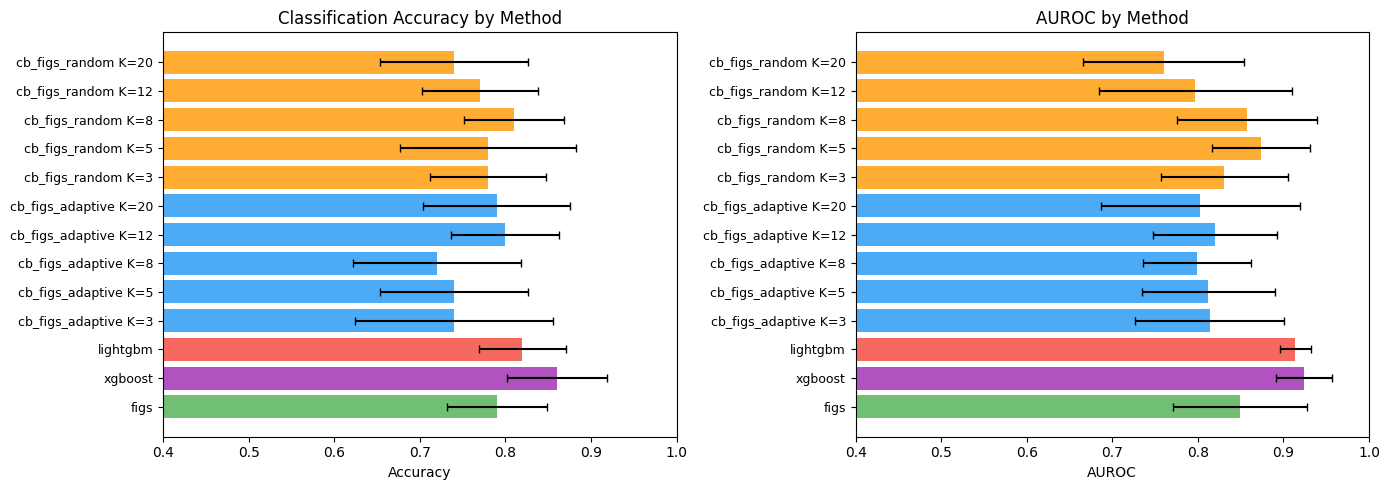


Method                      K     Acc   AUROC  Time(s)
figs                       -    0.790   0.849    0.324
xgboost                    -    0.860   0.924    2.464
lightgbm                   -    0.820   0.914    1.119
cb_figs_adaptive            3   0.740   0.814    0.117
cb_figs_adaptive            5   0.740   0.812    0.151
cb_figs_adaptive            8   0.720   0.799    0.239
cb_figs_adaptive           12   0.800   0.820    0.350
cb_figs_adaptive           20   0.790   0.803    0.495
cb_figs_random              3   0.780   0.831    0.117
cb_figs_random              5   0.780   0.874    0.155
cb_figs_random              8   0.810   0.857    0.222
cb_figs_random             12   0.770   0.797    0.332
cb_figs_random             20   0.740   0.760    0.477


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Accuracy by method ──
ax = axes[0]
methods = []
accs = []
errs = []
for s in summary:
    if s.get("accuracy_mean") is not None:
        label = s["config"]
        if s["K"] is not None:
            label += f" K={s['K']}"
        methods.append(label)
        accs.append(s["accuracy_mean"])
        errs.append(s.get("accuracy_std", 0))

if methods:
    colors = []
    for m in methods:
        if "adaptive" in m: colors.append("#2196F3")
        elif "random" in m: colors.append("#FF9800")
        elif "figs" in m.lower() and "cb" not in m.lower(): colors.append("#4CAF50")
        elif "xgboost" in m.lower(): colors.append("#9C27B0")
        elif "lightgbm" in m.lower(): colors.append("#F44336")
        else: colors.append("#607D8B")

    bars = ax.barh(range(len(methods)), accs, xerr=errs, color=colors, alpha=0.8, capsize=3)
    ax.set_yticks(range(len(methods)))
    ax.set_yticklabels(methods, fontsize=9)
    ax.set_xlabel("Accuracy")
    ax.set_title("Classification Accuracy by Method")
    ax.set_xlim(0.4, 1.0)

# ── Right: AUROC by method ──
ax = axes[1]
methods_auroc = []
aurocs = []
errs_auroc = []
for s in summary:
    if s.get("auroc_mean") is not None:
        label = s["config"]
        if s["K"] is not None:
            label += f" K={s['K']}"
        methods_auroc.append(label)
        aurocs.append(s["auroc_mean"])
        errs_auroc.append(s.get("auroc_std", 0))

if methods_auroc:
    colors2 = []
    for m in methods_auroc:
        if "adaptive" in m: colors2.append("#2196F3")
        elif "random" in m: colors2.append("#FF9800")
        elif "figs" in m.lower() and "cb" not in m.lower(): colors2.append("#4CAF50")
        elif "xgboost" in m.lower(): colors2.append("#9C27B0")
        elif "lightgbm" in m.lower(): colors2.append("#F44336")
        else: colors2.append("#607D8B")

    bars2 = ax.barh(range(len(methods_auroc)), aurocs, xerr=errs_auroc, color=colors2, alpha=0.8, capsize=3)
    ax.set_yticks(range(len(methods_auroc)))
    ax.set_yticklabels(methods_auroc, fontsize=9)
    ax.set_xlabel("AUROC")
    ax.set_title("AUROC by Method")
    ax.set_xlim(0.4, 1.0)

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=100, bbox_inches="tight")
plt.show()

# ── Print summary table ──
print("\n" + "=" * 65)
print(f"{'Method':<25} {'K':>3} {'Acc':>7} {'AUROC':>7} {'Time(s)':>8}")
print("=" * 65)
for s in summary:
    k_str = str(s['K']) if s['K'] else " - "
    acc = f"{s['accuracy_mean']:.3f}" if s.get('accuracy_mean') is not None else "   -  "
    auroc = f"{s['auroc_mean']:.3f}" if s.get('auroc_mean') is not None else "   -  "
    t = f"{s.get('train_time_sec_mean', 0):.3f}" if s.get('train_time_sec_mean') is not None else "   -  "
    print(f"{s['config']:<25} {k_str:>3} {acc:>7} {auroc:>7} {t:>8}")
print("=" * 65)